This notebook will plot total cloud cover maps to facilitate qualitative comparison with MODIS snapshots

In [1]:
import pandas as pd
import xarray as xr
import datetime as dt
import numpy as np
import utils
import wrfpp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from glob import glob
import seaborn as sns
import string

In [2]:
clt = xr.open_dataset(f"/mnt/data/model_output/ACI_OPT_2/CLT_2020-04-13_2020-04-17.nc").set_index(Time="XTIME")
clt = clt.assign_coords({
    "day": ("Time",[T.dt.day for T in clt.Time]),
    "longitude": (["south_north","west_east"],clt.XLONG.isel(Time=0).values),
    "latitude": (["south_north","west_east"],clt.XLAT.isel(Time=0).values),
})
clt_daily = clt.groupby(clt.Time.dt.day).mean().sel(day=16)

seaice = xr.open_dataset(f"/mnt/data/model_output/ACI_OPT_2/SEAICE_2020-04-13_2020-04-17.nc").set_index(Time="XTIME")
seaice = seaice.assign_coords({
    "day": ("Time",[T.dt.day for T in seaice.Time]),
    "longitude": (["south_north","west_east"],seaice.XLONG.isel(Time=0).values),
    "latitude": (["south_north","west_east"],seaice.XLAT.isel(Time=0).values),
})
landmask = xr.open_dataarray("/mnt/data/model_output/ACI_OPT_2/LANDMASK.nc").set_index(Time="XTIME")
land = (landmask).where(~(seaice>0))
ocean = (land!=1)

seaice_daily = seaice.where(ocean).groupby(seaice.Time.dt.day).mean().sel(day=16)


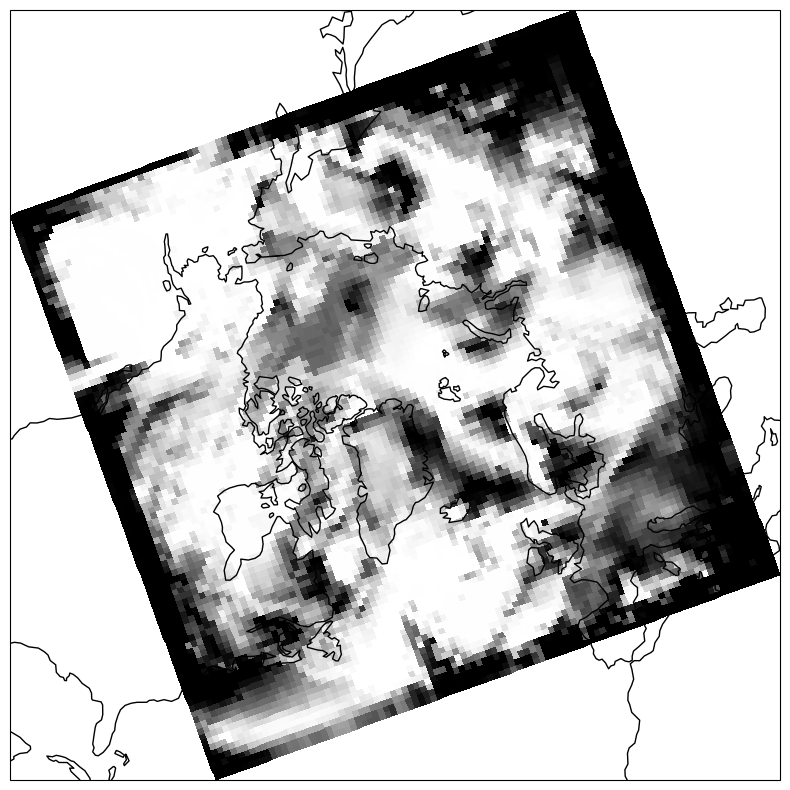

In [3]:
fig, ax = plt.subplots(
    1,1,
    figsize=(10,10),
    subplot_kw=dict(projection=ccrs.NorthPolarStereo(central_longitude=-45))
)

ax.coastlines()
# ax.set_extent([-180,180,60,90], crs=ccrs.PlateCarree())


map = ax.pcolormesh(
    seaice.longitude,
    seaice.latitude,
    100*seaice_daily.SEAICE,
    cmap="Blues_r",
    transform=ccrs.PlateCarree()
)

clouds = ax.pcolormesh(
    clt.longitude,
    clt.latitude,
    100*clt_daily.CLT,
    transform=ccrs.PlateCarree(),
    cmap="Greys_r"
)

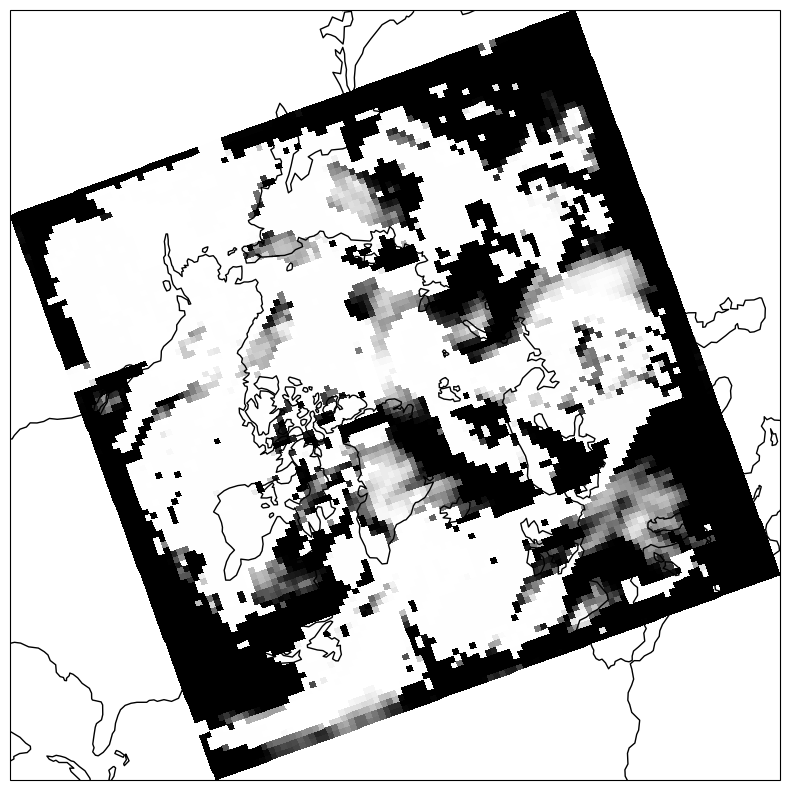

In [4]:
fig, ax = plt.subplots(
    1,1,
    figsize=(10,10),
    subplot_kw=dict(projection=ccrs.NorthPolarStereo(central_longitude=-45))
)

ax.coastlines()
# ax.set_extent([-180,180,60,90], crs=ccrs.PlateCarree())


clouds = ax.pcolormesh(
    clt.longitude,
    clt.latitude,
    100*clt.sel(Time=dt.datetime(2020,4,16,12)).CLT,
    transform=ccrs.PlateCarree(),
    cmap="Greys_r"
)

In [5]:
cre = xr.open_dataset(f"/mnt/data/model_output/thompson_derived_variables/sfc_cre_2020-04-13_2020-04-17.nc")
cre = cre.assign_coords({
    "day": ("Time",[T.dt.day for T in cre.Time]),
    "longitude": (["south_north","west_east"],cre.XLONG.isel(Time=0).values),
    "latitude": (["south_north","west_east"],cre.XLAT.isel(Time=0).values),
})
cre = cre.groupby(cre.Time.dt.day).mean().sel(day=16)


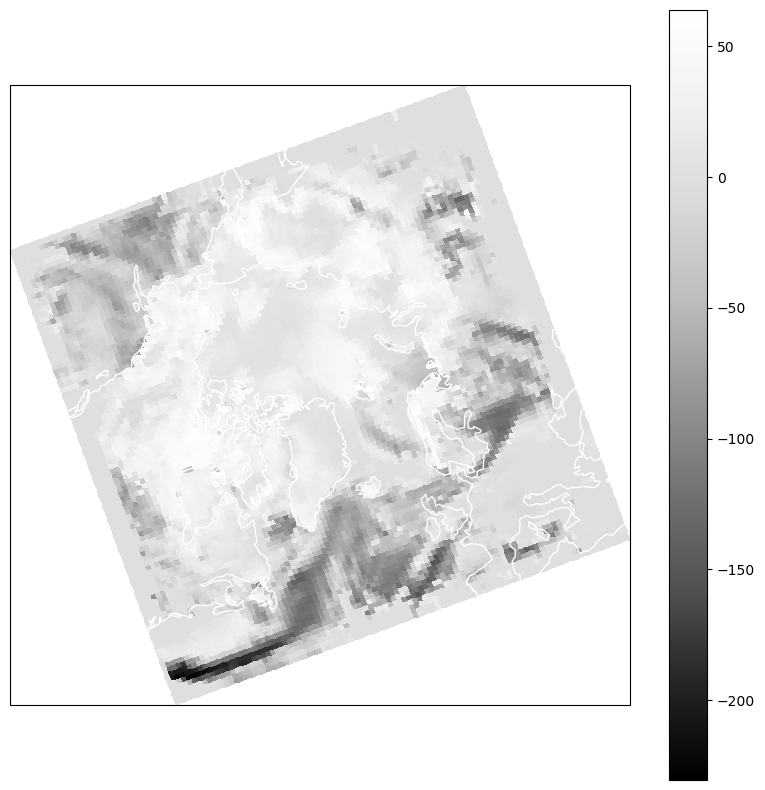

In [6]:
fig, ax = plt.subplots(
    1,1,
    figsize=(10,10),
    subplot_kw=dict(projection=ccrs.NorthPolarStereo(central_longitude=-45))
)

ax.coastlines(color="white")
# ax.set_extent([-180,180,60,90], crs=ccrs.PlateCarree())

clouds = ax.pcolormesh(
    cre.longitude,
    cre.latitude,
    cre["cloud_radiative_effect"].sel(pollution_state="polluted"),
    transform=ccrs.PlateCarree(),
    cmap="Greys_r"
)

plt.colorbar(clouds)

In [7]:
lwp = xr.open_dataset(f"/mnt/data/model_output/thompson_derived_variables/lwp_2020-04-13_2020-04-17.nc")
lwp = lwp.assign_coords({
    "day": ("Time",[T.dt.day for T in lwp.Time]),
    "longitude": (["south_north","west_east"],lwp.XLONG.isel(Time=0).values),
    "latitude": (["south_north","west_east"],lwp.XLAT.isel(Time=0).values),
})
lwp = lwp.groupby(lwp.Time.dt.day).mean()

iwp = xr.open_dataset(f"/mnt/data/model_output/thompson_derived_variables/iwp_2020-04-13_2020-04-17.nc")
iwp = iwp.assign_coords({
    "day": ("Time",[T.dt.day for T in iwp.Time]),
    "longitude": (["south_north","west_east"],iwp.XLONG.isel(Time=0).values),
    "latitude": (["south_north","west_east"],iwp.XLAT.isel(Time=0).values),
})
iwp = iwp.groupby(iwp.Time.dt.day).mean()

rwp = xr.open_dataset(f"/mnt/data/model_output/thompson_derived_variables/rwp_2020-04-13_2020-04-17.nc")
rwp = rwp.assign_coords({
    "day": ("Time",[T.dt.day for T in rwp.Time]),
    "longitude": (["south_north","west_east"],rwp.XLONG.isel(Time=0).values),
    "latitude": (["south_north","west_east"],rwp.XLAT.isel(Time=0).values),
})
rwp = rwp.groupby(rwp.Time.dt.day).mean()

twp = lwp["cloud liquid water path"] + iwp["Cloud ice water path"]


In [8]:
from matplotlib.colors import ListedColormap

# Pick a base colormap
base_cmap = matplotlib.cm.get_cmap("Greys_r")  # or "pink_r"

# Convert to array of RGBA values
cmap_array = base_cmap(np.linspace(0, 1, 256))

# Modify the alpha channel: make low values transparent
# cmap_array[:, -1] = np.linspace(0, 1, 256)  # alpha ramps from 0→1
# If you want "near-zero" only transparent (not the entire low end),
# you can instead threshold:
cmap_array[:,:-1] = 1
cmap_array[:, -1] = np.linspace(0, 1, 256)  # alpha ramps from 0→1
# cmap_array[:100, -1] = 0  # first 50 levels fully transparent
# cmap_array[100:, -1] = np.linspace(0, 1, 156)

# Create new colormap
transparent_cmap = ListedColormap(cmap_array)

/tmp/ipykernel_3569/2016182166.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_cmap = matplotlib.cm.get_cmap("Greys_r")  # or "pink_r"


2020-04-14


/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:862: FutureWarning: The behavior of this method will change in future versions. Use specific 'len(elem)' or 'elem is not None' test instead.
  if current and current.text == 'true':
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "1" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "2" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "3" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "4" already exists


2020-04-15


/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:862: FutureWarning: The behavior of this method will change in future versions. Use specific 'len(elem)' or 'elem is not None' test instead.
  if current and current.text == 'true':
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "1" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "2" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "3" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "4" already exists


2020-04-16


/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:862: FutureWarning: The behavior of this method will change in future versions. Use specific 'len(elem)' or 'elem is not None' test instead.
  if current and current.text == 'true':
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "1" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "2" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "3" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "4" already exists


2020-04-17


/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:862: FutureWarning: The behavior of this method will change in future versions. Use specific 'len(elem)' or 'elem is not None' test instead.
  if current and current.text == 'true':
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "1" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "2" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "3" already exists
  warnings.warn(msg, RuntimeWarning)
/workspaces/mosaic-wai-wrf-chem/.conda/lib/python3.11/site-packages/owslib/wmts.py:659: RuntimeWarning: TileMatrixLimits with tileMatrix "4" already exists


Text(-0.05, 0.5, 'Model cloud liquid water path')

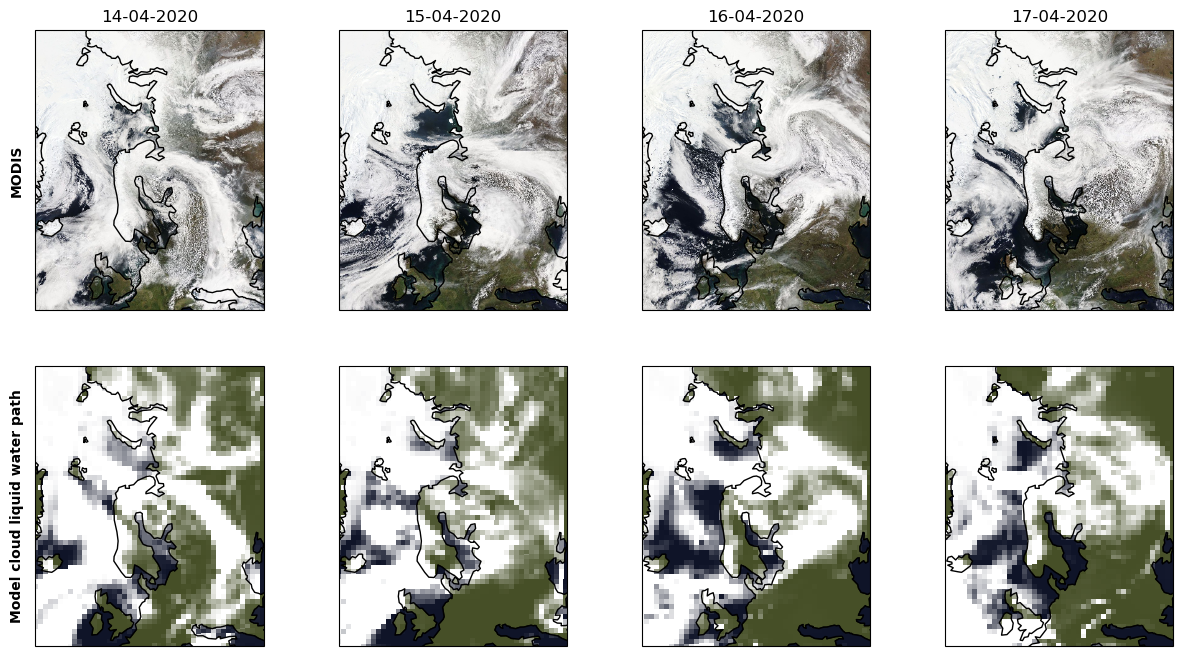

In [16]:
days = [14,15,16,17]

fig, axes = plt.subplots(
    2, len(days),
    figsize=(15,8),
    subplot_kw=dict(projection=ccrs.NorthPolarStereo(central_longitude=-25))
)

land = cfeature.NaturalEarthFeature(
    'physical', 'land', '110m',
    edgecolor='k',
)
land_c = '#464F27'
ocean = cfeature.NaturalEarthFeature(
    "physical", "ocean", "110m"
)
ocean_c = "#0F1428"


for n in range(len(days)):
    col = axes[:,n]
    d = days[n]
    for ax in col:
        ax.coastlines(zorder=4)
        ax.set_extent([-10,80,50,90], crs=ccrs.PlateCarree())
        ax.spines['geo'].set_zorder(5)

    # retrieve satellite data (code from Erin Raif)
    dateiso = f'2020-04-{d:02d}'
    print(dateiso)
    product = 'MODIS_Aqua_CorrectedReflectance_TrueColor'
    wmt_url = 'https://gibs.earthdata.nasa.gov/wmts/epsg4326/best/wmts.cgi'
    col[0].add_wmts(wmt_url, product, wmts_kwargs={'time': dateiso})

    # plot total cloud liquid water path and sea ice in white
    twp_day = twp.sel(day=d)
    # col[1].stock_img()
    col[1].add_feature(land, facecolor=land_c, zorder=1)
    col[1].add_feature(ocean, facecolor=ocean_c, zorder=1)
    clouds = col[1].pcolormesh(
        twp_day.longitude,
        twp_day.latitude,
        1000*twp_day.sel(pollution_state="polluted"),
        transform=ccrs.PlateCarree(),
        cmap=transparent_cmap,
        vmin=0, vmax=75,
        zorder=3
    )

    map = col[1].pcolormesh(
        seaice.longitude,
        seaice.latitude,
        100*seaice_daily.SEAICE.where(seaice_daily.SEAICE>0.15),
        cmap=transparent_cmap,
        transform=ccrs.PlateCarree(),
        zorder=2
    )
    col[0].set_title(f"{d}-04-2020")

# labels
axes[0,0].text(
    s="MODIS",
    x=-0.05, y=0.5,
    ha="right", va="center",
    multialignment="center",
    transform=axes[0,0].transAxes,
    weight="bold",
    rotation=90,
)
axes[1,0].text(
    s="Model cloud liquid water path",
    x=-0.05, y=0.5,
    ha="right", va="center",
    multialignment="center",
    transform=axes[1,0].transAxes,
    weight="bold",
    rotation=90,
)


Note: in above plots could collocate model output more precisely with MODIS overpass times instead of using daily means